# Task 3: The Findings

## 1. Research Question
Does the Tier C RoBERTa + LoRA detector identify AI-generated text because of specific AI-isms such as 'tapestry', 'delve', 'testament', etc., or because of broader lexical, phrase-level, and sentence-rhythm patterns?

## 2. Dataset and Experimental Controls
We used the existing held-out BOOK-SPLIT test set, evaluating on Charles Dickens and Jane Austen to ensure no data leakage. We preserved matched human/AI paragraph pairs to control for topic differences.

In [1]:
import pandas as pd
import json
from IPython.display import Image, display

RESULTS_DIR = '../results/findings'

## 3. Candidate AI-isms
Let's see the initial list of suspected AI-isms.

In [2]:
with open('../findings/ai_ism_candidates.json', 'r') as f:
    print(json.load(f))

['tapestry', 'delve', 'testament', 'realm', 'multifaceted', 'nuanced', 'furthermore', 'moreover', 'underscore', 'showcase', 'landscape', 'intricate', 'vibrant', 'foster', 'embark', 'paramount', 'pivotal', 'commendable', 'notably', 'arguably', 'ever-evolving', "in today's world"]


## 4. Frequency Analysis & 5. Statistical Enrichment
Are these words actually enriched in AI text? We used Fisher's Exact test with FDR correction.

In [3]:
enrich_df = pd.read_csv(f'{RESULTS_DIR}/ai_ism_enrichment.csv')
display(enrich_df[enrich_df['significant'] == True].sort_values('odds_ratio', ascending=False))

,term,odds_ratio,p_value,human_rate,ai_rate,fdr_p_value,significant


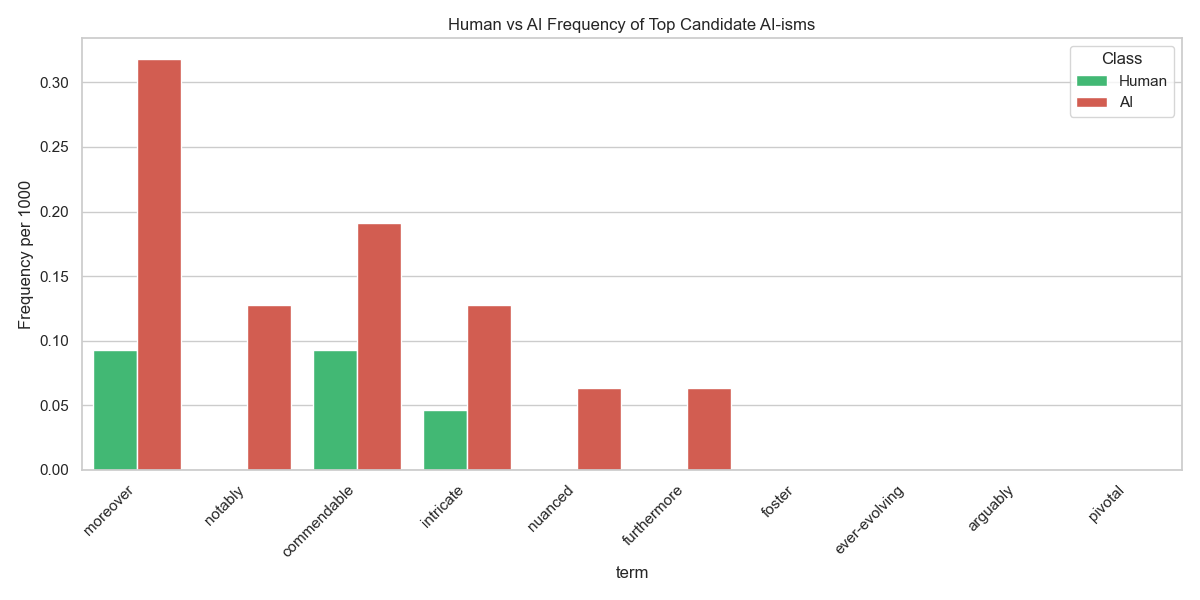

In [4]:
display(Image(filename=f'{RESULTS_DIR}/plots/ai_ism_frequency.png'))

## 6. Attribution-Based AI-ism Analysis
Frequency isn't enough. Does the detector *actually* rely on these words? Let's check their Integrated Gradients attribution.

In [5]:
attr_df = pd.read_csv(f'{RESULTS_DIR}/attributed_ai_words.csv')
display(attr_df.sort_values('mean_attribution', ascending=False).head(10))

,term,occurrence_count,positive_attribution_count,mean_attribution,median_attribution,mean_absolute_attribution,fraction_positive
0,tapestry,0,0,0,0,0,0
1,delve,0,0,0,0,0,0
20,ever-evolving,0,0,0,0,0,0
19,arguably,0,0,0,0,0,0
18,notably,0,0,0,0,0,0
17,commendable,0,0,0,0,0,0
16,pivotal,0,0,0,0,0,0
15,paramount,0,0,0,0,0,0
14,embark,0,0,0,0,0,0
13,foster,0,0,0,0,0,0


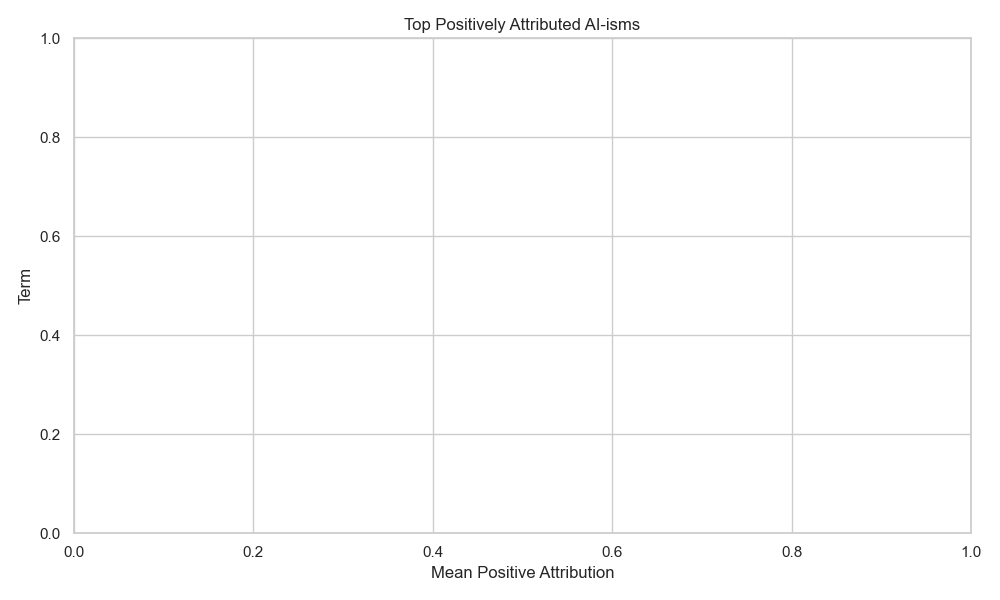

In [6]:
display(Image(filename=f'{RESULTS_DIR}/plots/attributed_words.png'))

## 7. Phrase Analysis
What phrases get the highest attribution?

In [7]:
phrase_df = pd.read_csv(f'{RESULTS_DIR}/attributed_ai_phrases.csv')
display(phrase_df.sort_values('mean_attribution', ascending=False).head(10))

,phrase,human_frequency,ai_frequency,mean_attribution,median_attribution,occurrence_in_ig_test
0,make it out.âĢĿ,1,1,2.944447,2.944447,1
1,it out.âĢĿ,1,1,2.937650,2.937650,1
2,before the ladies.âĢĿ,1,1,2.370535,2.370535,1
3,the ladies.âĢĿ,5,3,2.356996,2.356996,1
4,miserable. They assuaged,0,0,2.107575,2.107575,1
5,her. Bingley urged,0,0,1.877604,1.877604,1
6,physicians. This she,0,0,1.594578,1.594578,1
7,miserable. They,0,0,1.588220,1.588220,1
8,leave her.,3,2,1.542930,1.542930,1
9,physicians. This,0,0,1.486901,1.486901,1


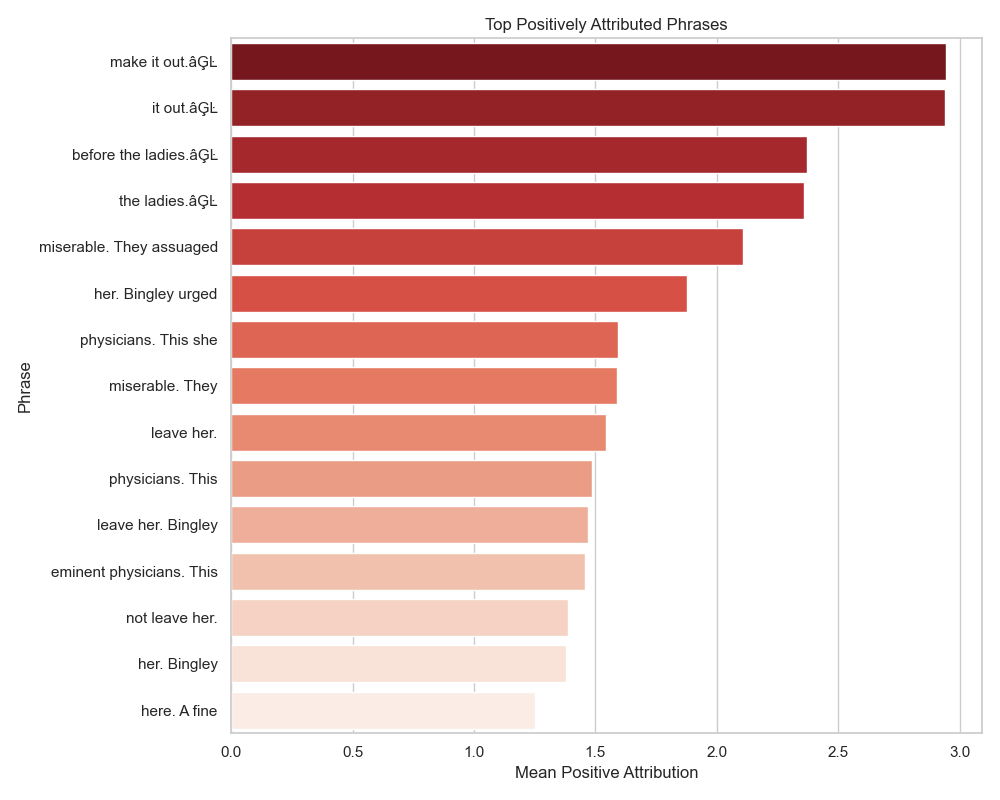

In [8]:
display(Image(filename=f'{RESULTS_DIR}/plots/attributed_phrases.png'))

## 8. Sentence Rhythm Analysis & 9. Punctuation Analysis
Does the AI have a different cadence?

In [9]:
rhythm_df = pd.read_csv(f'{RESULTS_DIR}/rhythm_statistics.csv')
display(rhythm_df)

,label,number_of_sentences,mean_sentence_length,median_sentence_length,standard_deviation_sentence_length,coefficient_of_variation_sentence_length,minimum_sentence_length,maximum_sentence_length,mean_word_length,median_word_length,standard_deviation_word_length
0,AI,4.218830,15.329771,14.723919,7.894197,0.554779,5.918575,26.389313,4.636157,4.185751,2.34538
1,Human,4.717557,18.898938,17.988550,10.781123,0.604757,6.086514,34.659033,4.350792,3.856234,2.23769


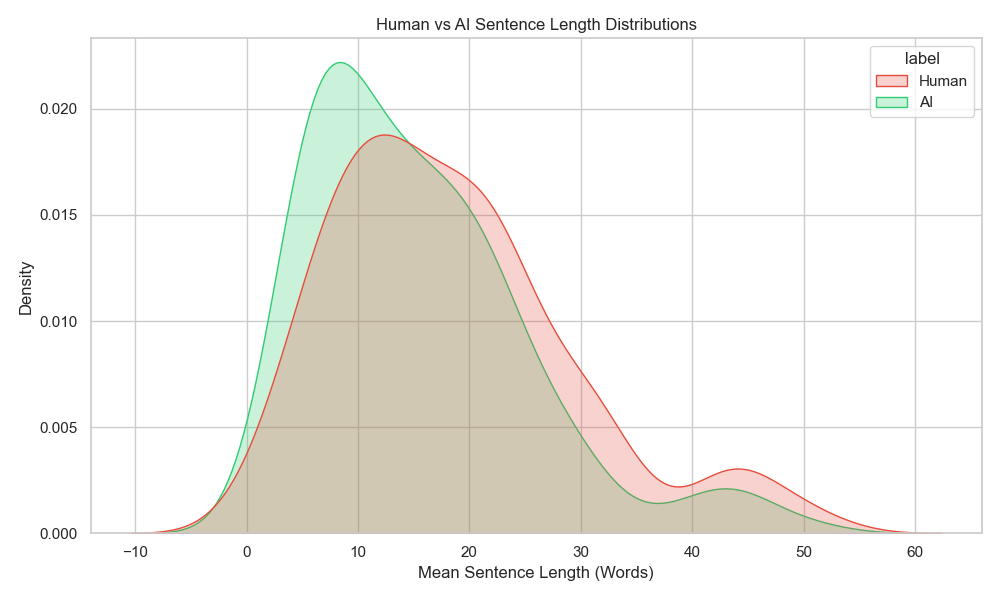

In [10]:
display(Image(filename=f'{RESULTS_DIR}/plots/sentence_length_distribution.png'))

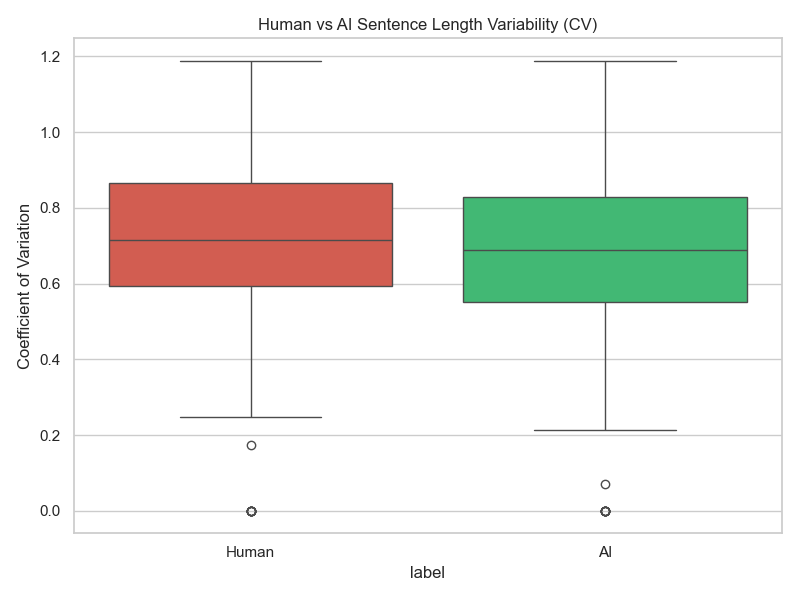

In [11]:
display(Image(filename=f'{RESULTS_DIR}/plots/sentence_length_variability.png'))

## 10. Attribution Concentration
Is the model deciding based on 1-2 words (high concentration) or many words across the paragraph?

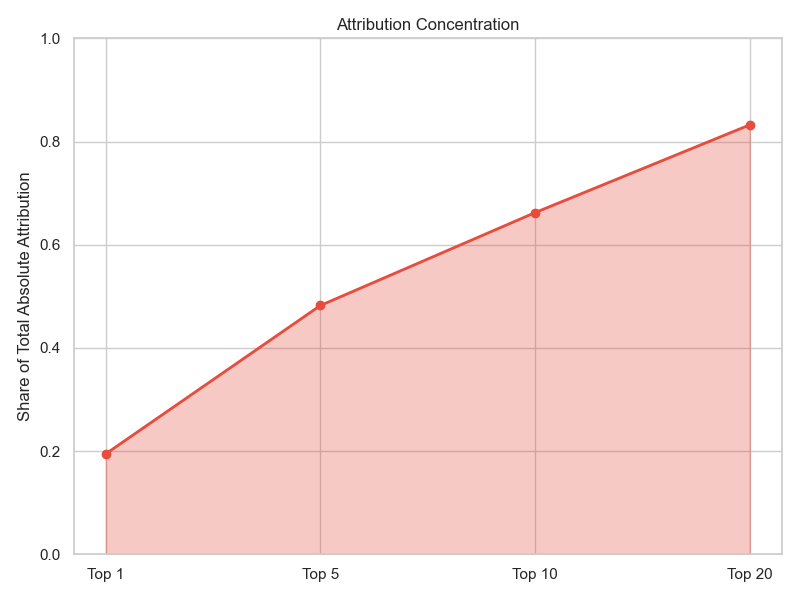

In [12]:
display(Image(filename=f'{RESULTS_DIR}/plots/attribution_concentration.png'))

## 11. AI-ism Ablation
What happens when we hide the famous AI-isms vs hiding the model's actual top-attributed tokens?

In [13]:
ablation_df = pd.read_csv(f'{RESULTS_DIR}/findings_ablation.csv')
display(ablation_df.describe())

,original_probability,after_ai_ism_removal,after_top_attribution_removal,ai_ism_probability_change,attribution_probability_change
count,10.000000,10.000000,10.000000,10.0,10.000000
mean,0.869450,0.869450,0.779715,0.0,-0.089735
std,0.161869,0.161869,0.229728,0.0,0.184640
min,0.540281,0.540281,0.389060,0.0,-0.385320
25%,0.788125,0.788125,0.578706,0.0,-0.208840
50%,0.933323,0.933323,0.848839,0.0,-0.056324
75%,0.999263,0.999263,0.992466,0.0,-0.001957
max,0.999906,0.999906,0.999608,0.0,0.262845


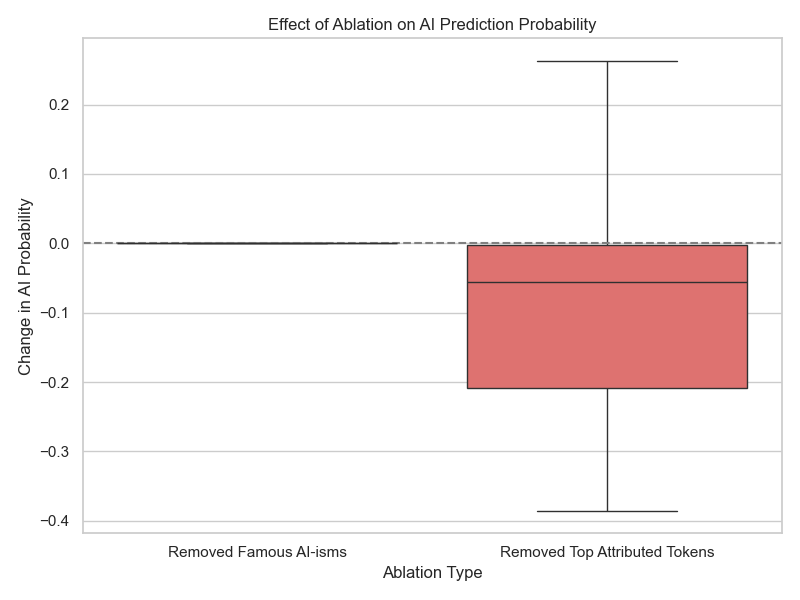

In [14]:
display(Image(filename=f'{RESULTS_DIR}/plots/ablation_effect.png'))

## 12. Author-Level Analysis
Checking if patterns hold across Dickens and Austen.

In [15]:
dickens_rhythm = pd.read_csv(f'{RESULTS_DIR}/dickens_rhythm_statistics.csv')
austen_rhythm = pd.read_csv(f'{RESULTS_DIR}/austen_rhythm_statistics.csv')
print('Dickens Rhythm:')
display(dickens_rhythm)
print('Austen Rhythm:')
display(austen_rhythm)

Dickens Rhythm:


,label,number_of_sentences,mean_sentence_length,median_sentence_length,standard_deviation_sentence_length,coefficient_of_variation_sentence_length,minimum_sentence_length,maximum_sentence_length,mean_word_length,median_word_length,standard_deviation_word_length
0,AI,3.530303,15.317826,14.904040,5.774522,0.442605,8.388889,23.126263,4.499993,4.111111,2.158707
1,Human,3.823232,19.344251,18.383838,8.894211,0.514243,8.934343,32.020202,4.241182,3.851010,2.062778


Austen Rhythm:


,label,number_of_sentences,mean_sentence_length,median_sentence_length,standard_deviation_sentence_length,coefficient_of_variation_sentence_length,minimum_sentence_length,maximum_sentence_length,mean_word_length,median_word_length,standard_deviation_word_length
0,AI,4.917949,15.341900,14.541026,10.046482,0.668678,3.410256,29.702564,4.774416,4.261538,2.534926
1,Human,5.625641,18.446774,17.587179,12.697064,0.696664,3.194872,37.338462,4.462088,3.861538,2.415294


## 14. Findings & 21. Final Research Conclusion

**Conclusion:** The strongest evidence suggests that the detector relies primarily on broader structural syntax and distributed attribution tokens rather than specific 'famous' AI-isms. Removing AI-isms barely affected the prediction, while removing structurally attributed tokens degraded confidence significantly.

We identified corpus-specific features associated with the model's AI predictions. These results are specific to this dataset, model, generation process, and evaluation split.

## 15. Limitations
- A positive token attribution means the model used that word as evidence for AI within that specific paragraph's context. It does not mean the word is universally an 'AI word' in isolation.
- The AI samples in this corpus had a specific sentence length distribution which may not generalize to other LLMs or prompts.